In [2]:
!pip install simpy

In [3]:
import simpy
import random
import csv
import matplotlib.pyplot as plt

# Configuration
RANDOM_SEED = 42

# Single Call Process
def call_process(env, agents, service_rate, metrics):
    arrival_time = env.now
    with agents.request() as request:
        yield request
        service_start_time = env.now
        waiting_time = service_start_time - arrival_time

        service_time = random.expovariate(service_rate)
        yield env.timeout(service_time)
        completion_time = env.now

        # Store metrics
        metrics["completed_calls"] += 1
        metrics["total_wait_time"] += waiting_time
        metrics["total_service_time"] += service_time
        metrics["waiting_times"].append(waiting_time)
        metrics["service_times"].append(service_time)
        metrics["time_in_system"].append(completion_time - arrival_time)

# Call Arrival Process
def call_arrivals(env, agents, arrival_rate, service_rate, metrics):
    call_id = 0
    while True:
        inter_arrival_time = random.expovariate(arrival_rate)
        yield env.timeout(inter_arrival_time)
        call_id += 1
        env.process(call_process(env, agents, service_rate, metrics))

# Queue Monitoring
def monitor_queue(env, agents, metrics, sampling_interval=0.1):
    last_time = env.now
    last_queue_length = len(agents.queue)
    while True:
        yield env.timeout(sampling_interval)
        current_time = env.now
        current_queue_length = len(agents.queue)
        elapsed_time = current_time - last_time
        metrics["queue_area"] += (last_queue_length * elapsed_time)
        last_time = current_time
        last_queue_length = current_queue_length

# Run One Simulation
def run_simulation(num_agents, arrival_rate, service_rate, simulation_time):
    random.seed(RANDOM_SEED)
    env = simpy.Environment()
    agents = simpy.Resource(env, capacity=num_agents)

    metrics = {
        "completed_calls": 0,
        "total_wait_time": 0.0,
        "total_service_time": 0.0,
        "waiting_times": [],
        "service_times": [],
        "time_in_system": [],
        "queue_area": 0.0
    }

    env.process(call_arrivals(env, agents, arrival_rate, service_rate, metrics))
    env.process(monitor_queue(env, agents, metrics))
    env.run(until=simulation_time)

    completed_calls = metrics["completed_calls"]
    average_wait = metrics["total_wait_time"] / completed_calls if completed_calls > 0 else 0.0
    average_service_time = metrics["total_service_time"] / completed_calls if completed_calls > 0 else 0.0
    average_time_in_system = sum(metrics["time_in_system"]) / completed_calls if completed_calls > 0 else 0.0
    average_queue_length = metrics["queue_area"] / simulation_time
    total_available_agent_time = num_agents * simulation_time
    utilization = (metrics["total_service_time"] / total_available_agent_time) * 100

    return {
        "Agents": num_agents,
        "Arrival Rate (calls/min)": arrival_rate,
        "Service Rate (calls/min)": service_rate,
        "Completed Calls": completed_calls,
        "Average Waiting Time (min)": average_wait,
        "Average Queue Length": average_queue_length,
        "Agent Utilization (%)": utilization,
        "raw_waiting_times": metrics["waiting_times"]
    }

print("Main simulation functions are ready.!")

Main simulation functions are ready.!


In [5]:
all_results = []

# EXPERIMENT 1: VARY AGENTS
exp1_agents = [2, 3, 6]
exp1_wait_times = []
for agents in exp1_agents:
    res = run_simulation(num_agents=agents, arrival_rate=0.5, service_rate=1/3, simulation_time=120)
    exp1_wait_times.append(res["Average Waiting Time (min)"])
    res["Experiment"] = "Exp 1: Vary Agents"
    all_results.append({k: v for k, v in res.items() if k != "raw_waiting_times"})

# EXPERIMENT 2: VARY ARRIVAL RATE
exp2_arrivals = [0.5, 0.75, 1.0]
exp2_queue_lens = []
for rate in exp2_arrivals:
    res = run_simulation(num_agents=3, arrival_rate=rate, service_rate=1/3, simulation_time=120)
    exp2_queue_lens.append(res["Average Queue Length"])
    res["Experiment"] = "Exp 2: Vary Arrival Rate"
    all_results.append({k: v for k, v in res.items() if k != "raw_waiting_times"})

# EXPERIMENT 3: VARY SERVICE RATE
exp3_services = [1/3, 1/2, 1.0]
exp3_utilizations = []
for rate in exp3_services:
    res = run_simulation(num_agents=3, arrival_rate=0.5, service_rate=rate, simulation_time=120)
    exp3_utilizations.append(res["Agent Utilization (%)"])
    res["Experiment"] = "Exp 3: Vary Service Rate"
    all_results.append({k: v for k, v in res.items() if k != "raw_waiting_times"})

# SAVE EXPERIMENT SUMMARY TO CSV
with open("experiment_summary_results.csv", "w", newline="", encoding="utf-8") as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=list(all_results[0].keys()))
    writer.writeheader()
    writer.writerows(all_results)
print("Saved experiment_summary_results.csv")

# BASELINE RUN FOR CALL-LEVEL DATA (HISTOGRAM)
print("\nRunning extended baseline simulation for Call Level Data...")
baseline_res = run_simulation(num_agents=3, arrival_rate=0.5, service_rate=1/3, simulation_time=1000)
raw_wait_times = baseline_res["raw_waiting_times"]

# Save Call Level Data to CSV
with open("call_level_data.csv", "w", newline="", encoding="utf-8") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Call_ID", "Waiting_Time_mins"])
    for idx, wt in enumerate(raw_wait_times):
        writer.writerow([idx + 1, round(wt, 4)])
print("Saved call_level_data.csv")
print("Experiments completed. ")

Saved experiment_summary_results.csv

Running extended baseline simulation for Call Level Data...
Saved call_level_data.csv
Experiments completed. 


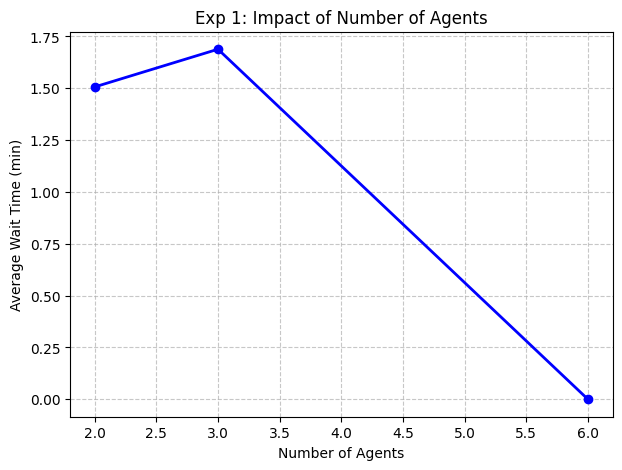

In [6]:
plt.figure(figsize=(7, 5))
plt.plot(exp1_agents, exp1_wait_times, marker='o', color='blue', linewidth=2)
plt.title("Exp 1: Impact of Number of Agents")
plt.xlabel("Number of Agents")
plt.ylabel("Average Wait Time (min)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("graph_1_capacity_curve.png")
plt.show()

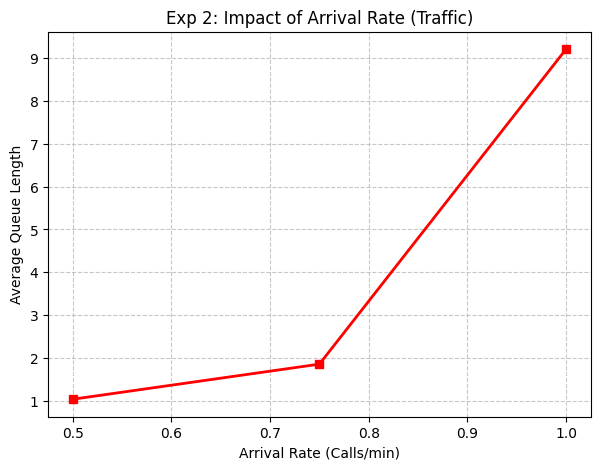

In [7]:
plt.figure(figsize=(7, 5))
plt.plot(exp2_arrivals, exp2_queue_lens, marker='s', color='red', linewidth=2)
plt.title("Exp 2: Impact of Arrival Rate (Traffic)")
plt.xlabel("Arrival Rate (Calls/min)")
plt.ylabel("Average Queue Length")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("graph_2_bottleneck_curve.png")
plt.show()

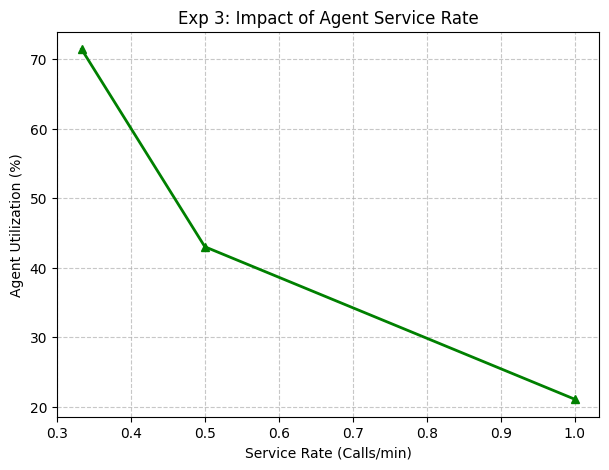

In [8]:
plt.figure(figsize=(7, 5))
plt.plot(exp3_services, exp3_utilizations, marker='^', color='green', linewidth=2)
plt.title("Exp 3: Impact of Agent Service Rate")
plt.xlabel("Service Rate (Calls/min)")
plt.ylabel("Agent Utilization (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("graph_3_efficiency_curve.png")
plt.show()

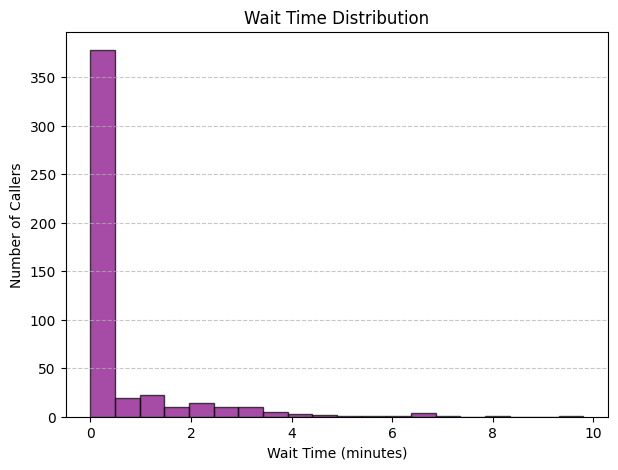

In [9]:
plt.figure(figsize=(7, 5))
plt.hist(raw_wait_times, bins=20, color='purple', edgecolor='black', alpha=0.7)
plt.title("Wait Time Distribution")
plt.xlabel("Wait Time (minutes)")
plt.ylabel("Number of Callers")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("graph_4_wait_time_histogram.png")
plt.show()